In [1]:
import akshare as ak
import pandas as pd
from datetime import datetime

def get_hk_stock_data(symbol: str):
    """
    获取港股后复权数据，仅保留交易日（不补全非交易日）
    """
    try:
        # 获取数据
        stock_data = ak.stock_hk_daily(symbol=symbol, adjust="qfq")
        
        if stock_data.empty:
            print(f"警告：{symbol} 返回空数据")
            return pd.DataFrame()
        
        print(f"{symbol} 原始数据 shape: {stock_data.shape}")
        
        # 确保 date 是 datetime 类型
        if 'date' in stock_data.columns:
            stock_data['date'] = pd.to_datetime(stock_data['date'], errors='coerce')
        else:
            print(f"错误：{symbol} 数据中无 'date' 列")
            return pd.DataFrame()
        
        # 筛选所需列
        keep_cols = ['date', 'open', 'high', 'low', 'close', 'volume']
        available_cols = [c for c in keep_cols if c in stock_data.columns]
        data = stock_data[available_cols].copy()
        
        # 日期范围过滤
        start_date = pd.to_datetime("2024-05-27")
        end_date = pd.to_datetime("2026-01-31")
        
        data = data[(data['date'] >= start_date) & (data['date'] <= end_date)]
        
        if data.empty:
            print(f"警告：{symbol} 在 {start_date.date()} ~ {end_date.date()} 区间无数据")
            return pd.DataFrame()
        
        # 设置索引并排序
        data = data.set_index('date').sort_index()
        
        # --- 修改处：不再进行 reindex(full_index).ffill() ---
        # 直接在原始交易日数据上添加 Ticker
        data['Ticker'] = symbol.zfill(5) 
        
        print(f"{symbol} 处理后 shape: {data.shape} (仅含交易日)")
        return data
    
    except Exception as e:
        print(f"获取 {symbol} 失败: {str(e)}")
        return pd.DataFrame()


def save_multiple_hk_stocks(tickers, filename):
    all_data = []
    for ticker in tickers:
        df = get_hk_stock_data(ticker)
        if not df.empty:
            all_data.append(df)
        print(f"处理完成 {ticker}, 交易日数: {len(df)}")
    
    if not all_data:
        print("所有股票均无数据，无法保存")
        return
    
    final_df = pd.concat(all_data)
    
    # 把日期索引转为普通列，命名为 'date'
    final_df = final_df.reset_index(names='date')
    
    # 日期格式统一（保持你的风格）
    final_df['date'] = final_df['date'].dt.strftime('%Y/%m/%d')
    
    # 保存
    final_df.to_csv(filename, encoding="utf-8-sig", index=False)
    print(f"所有数据已保存至: {filename}")
    print(f"总行数: {len(final_df)}, 列名: {final_df.columns.tolist()}")


# 执行：使用正确的阿里巴巴代码 09988
tickers = ["00700", "09988", "01810"]
save_multiple_hk_stocks(tickers, "data/hk_stocks.csv")

00700 原始数据 shape: (5361, 6)
00700 处理后 shape: (416, 6) (仅含交易日)
处理完成 00700, 交易日数: 416
09988 原始数据 shape: (1564, 6)
09988 处理后 shape: (416, 6) (仅含交易日)
处理完成 09988, 交易日数: 416
01810 原始数据 shape: (1907, 6)
01810 处理后 shape: (416, 6) (仅含交易日)
处理完成 01810, 交易日数: 416
所有数据已保存至: data/hk_stocks.csv
总行数: 1248, 列名: ['date', 'open', 'high', 'low', 'close', 'volume', 'Ticker']


In [2]:
import pandas as pd
import re
import os
OUTPUT_RAW_DIR = "data/raw"
INPUT_DIR = "data/weibo_hot_history"
# 腾讯控股 (00700.HK)
words_tencent = [
    # 主词
    '腾讯',
    # 高频子产品/平台
    '微信', 'QQ', '王者荣耀', '和平精英', '游戏版号'
    # 人物
    '马化腾', '刘炽平'
]
# 阿里巴巴 (09988.HK)
words_alibaba = [
    '阿里',      # 主词
    '淘宝', '天猫', '支付宝', '菜鸟', '盒马' # 高频独立平台
    '马云',                   # 人物
    '双11', '618'  # 高频独立事件/促销/政策
]

# 小米集团 (01810.HK)
words_xiaomi = [
    # 主词
    '小米',
    # 高频子产品/平台
    'SU7'
    # 人物
    '雷军'
]

#
def parse_md_file(filename):
    with open(filename, "r", encoding="utf-8") as f:
        text = f.read()
    #提取日期
    pattern = r'(\d{4}-\d{2}-\d{2})'          # 匹配 YYYY-MM-DD
    
    match = re.search(pattern, filename)
    if match:
        date = match.group(1)
    else:
        print("未找到日期")
        
    # 正则匹配每一条热搜
    pattern = re.compile(r"(\d+)\.\s+\[(.*?)\]\(.*?\)\s+`(.*?)`\s+-\s+(\d+)")
    matches = pattern.findall(text)

    data = []
    for rank, keyword, category, hot_value in matches:
        hot_value_int = int(hot_value)
        # 跳过 hot_value 为 0 的条目
        if hot_value_int == 0:
            continue
        #忽略大小写
        keyword_lower   = keyword.lower()
        category_lower  = category.lower()
        
        is_tencent = any(word.lower() in keyword_lower or word.lower() in category_lower 
                         for word in words_tencent)
        
        is_alibaba = any(word.lower() in keyword_lower or word.lower() in category_lower 
                        for word in words_alibaba)
        
        is_xiaomi = any(word.lower() in keyword_lower or word.lower() in category_lower 
                        for word in words_xiaomi)
        data.append({
            "rank": int(rank),
            "keyword": keyword,
            "category": category,
            "hot_value": int(hot_value),
            "date": date,
            "is_tencent": is_tencent,
            "is_alibaba": is_alibaba,
            "is_xiaomi": is_xiaomi
        })

    return data
def parse_all_files(folder_path):
    """批量解析文件夹下所有 md 文件"""
    all_data = []
    for file in os.listdir(folder_path):
        if file.endswith(".md"):
            filepath = os.path.join(folder_path, file)
            # print(f"Parsing {filepath} ...")
            all_data.extend(parse_md_file(filepath))
    df = pd.DataFrame(all_data)
    return df
# 主程序
if __name__ == "__main__":
    df = parse_all_files(INPUT_DIR)

    # 只保存 True 的条目，并去掉布尔列
    df_tencent = df[df["is_tencent"]].drop(columns=["is_tencent", "is_alibaba", "is_xiaomi"])
    df_alibaba = df[df["is_alibaba"]].drop(columns=["is_tencent", "is_alibaba", "is_xiaomi"])
    df_xiaomi = df[df["is_xiaomi"]].drop(columns=["is_tencent", "is_alibaba", "is_xiaomi"])

    os.makedirs("data", exist_ok=True)

    df_tencent.to_csv(os.path.join(OUTPUT_RAW_DIR, "tencent.csv"), index=False, encoding="utf-8-sig")
    df_alibaba.to_csv(os.path.join(OUTPUT_RAW_DIR, "alibaba.csv"), index=False, encoding="utf-8-sig")
    df_xiaomi.to_csv(os.path.join(OUTPUT_RAW_DIR, "xiaomi.csv"),  index=False, encoding="utf-8-sig")

    print("已保存tencent.csv, alibaba.csv, xiaomi.csv, path = " + OUTPUT_RAW_DIR)

已保存tencent.csv, alibaba.csv, xiaomi.csv, path = data/raw


In [3]:
import pandas as pd
from transformers import pipeline
import torch
import os

# 配置
MODEL_NAME = "IDEA-CCNL/Erlangshen-Roberta-110M-Sentiment"
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

EWMA_SPAN = 7
OUTPUT_RAW_DIR = "data/raw"
OUTPUT_PROCESSED_DIR = "data/processed"
os.makedirs(OUTPUT_PROCESSED_DIR, exist_ok=True)

# 加载情感模型
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    device=DEVICE,
    dtype=torch.float16 if DEVICE != "cpu" else None
)

def get_sentiment_score(text):
    """返回 [-1, 1] 分数"""
    if pd.isna(text) or not text.strip():
        return 0.0
    try:
        result = sentiment_pipeline(text, truncation=True, max_length=512)[0]
        if '1' in result['label'] or 'positive' in result['label'].lower():
            return result['score']
        else:
            return -result['score']
    except Exception as e:
        print(f"情感分析出错: {text[:30]}... → {e}")
        return 0.0

def compute_daily_sentiment(df_stock, stock_name):
    if df_stock.empty:
        print(f"{stock_name} 数据为空")
        return pd.DataFrame(columns=['raw_sentiment', 'sentiment_smooth', 'topic_count', 'total_heat'])
    
    df_stock['date'] = pd.to_datetime(df_stock['date'], errors='coerce')
    df_stock = df_stock.dropna(subset=['date']).sort_values('date')
    
    grouped = df_stock.groupby('date')
    results = []
    
    for date, group in grouped:
        group = group.copy()
        group['score'] = group['keyword'].apply(get_sentiment_score)
        
        total_heat = group['hot_value'].sum()
        if total_heat <= 0:
            weighted = 0.0
        else:
            weighted = (group['score'] * group['hot_value']).sum() / total_heat
            
        results.append({
            'date': date,
            'raw_sentiment': weighted,
            'topic_count': len(group),
            'total_heat': total_heat
        })
    
    df_daily = pd.DataFrame(results).set_index('date').sort_index()
    
    # 只做 EWMA 平滑，不填充缺失
    df_daily['sentiment_smooth'] = df_daily['raw_sentiment'].ewm(span=EWMA_SPAN, adjust=False).mean()
    
    print(f"{stock_name}: {len(df_daily)} 个有效日期，NaN 数量: {df_daily['sentiment_smooth'].isna().sum()}")
    
    return df_daily

# 读取数据
df_tencent = pd.read_csv(os.path.join(OUTPUT_RAW_DIR, "tencent.csv"), encoding="utf-8-sig")
df_alibaba = pd.read_csv(os.path.join(OUTPUT_RAW_DIR, "alibaba.csv"), encoding="utf-8-sig")
df_xiaomi  = pd.read_csv(os.path.join(OUTPUT_RAW_DIR, "xiaomi.csv"),  encoding="utf-8-sig")

# 计算
sent_tencent = compute_daily_sentiment(df_tencent, "腾讯")
sent_alibaba = compute_daily_sentiment(df_alibaba, "阿里")
sent_xiaomi  = compute_daily_sentiment(df_xiaomi,  "小米")

# 对个股 df保留4位小数
sent_tencent['sentiment_smooth'] = sent_tencent['sentiment_smooth'].round(4)
sent_alibaba['sentiment_smooth'] = sent_alibaba['sentiment_smooth'].round(4)
sent_xiaomi['sentiment_smooth']  = sent_xiaomi['sentiment_smooth'].round(4)

# 合并（缺失日期为 NaN）
merged = pd.concat([
    sent_tencent['sentiment_smooth'].rename('sentiment_tencent'),
    sent_alibaba['sentiment_smooth'].rename('sentiment_alibaba'),
    sent_xiaomi['sentiment_smooth'].rename('sentiment_xiaomi')
], axis=1)

# 保存为 CSV（所有结果都用 CSV）
merged.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "daily_sentiment.csv"),
              encoding="utf-8-sig",
              na_rep='NaN',
              index=True)  # 保留 date 作为索引列

# 分别保存个股（也用 CSV）
sent_tencent.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_tencent.csv"),
                    encoding="utf-8-sig",
                    na_rep='NaN',
                    index=True)

sent_alibaba.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_alibaba.csv"),
                    encoding="utf-8-sig",
                    na_rep='NaN',
                    index=True)

sent_xiaomi.to_csv(os.path.join(OUTPUT_PROCESSED_DIR, "sentiment_xiaomi.csv"),
                   encoding="utf-8-sig",
                   na_rep='NaN',
                   index=True)

print("\n完成。所有结果已保存为 CSV 格式：")
print(f"  {OUTPUT_PROCESSED_DIR}/daily_sentiment.csv       (合并表，含三支股票情绪)")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_tencent.csv     (腾讯情绪)")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_alibaba.csv     (阿里情绪)")
print(f"  {OUTPUT_PROCESSED_DIR}/sentiment_xiaomi.csv      (小米情绪)")
print("缺失日期情绪值为 NaN，未做任何填充。")

Using device: mps


Device set to use mps


腾讯: 481 个有效日期，NaN 数量: 0
阿里: 245 个有效日期，NaN 数量: 0
小米: 334 个有效日期，NaN 数量: 0

完成。所有结果已保存为 CSV 格式：
  data/processed/daily_sentiment.csv       (合并表，含三支股票情绪)
  data/processed/sentiment_tencent.csv     (腾讯情绪)
  data/processed/sentiment_alibaba.csv     (阿里情绪)
  data/processed/sentiment_xiaomi.csv      (小米情绪)
缺失日期情绪值为 NaN，未做任何填充。


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=== 开始情绪-股价相关性分析 ===")

# 加载数据
STOCK_FILE = "data/hk_stocks.csv"
SENTIMENT_FILE = os.path.join("data/processed", "daily_sentiment.csv")

# 1. 读取股价（此时只有交易日）
df_price = pd.read_csv(STOCK_FILE, parse_dates=['date'], date_format='%Y/%m/%d')
df_price['Ticker'] = df_price['Ticker'].astype(str).str.zfill(5)

# 2. 读取情绪（包含每天）
df_sent = pd.read_csv(SENTIMENT_FILE, parse_dates=['date'], index_col='date')
df_sent.index = pd.to_datetime(df_sent.index)

# 股票映射
tickers = {
    '00700': ('腾讯', 'sentiment_tencent'),
    '09988': ('阿里巴巴', 'sentiment_alibaba'),
    '01810': ('小米', 'sentiment_xiaomi')
}

results = []
for ticker, (name, sent_col) in tickers.items():
    # --- 股价处理 ---
    df_p = df_price[df_price['Ticker'] == ticker].copy().set_index('date').sort_index()
    df_p['ret'] = df_p['close'].pct_change()          # 简单收益率
    
    # --- 合并情绪逻辑修改 ---
    if sent_col not in df_sent.columns:
        print(f"警告：{name} 情绪列 {sent_col} 不存在，跳过")
        continue

    # 【核心修改点】使用 how='right' 以价格表（交易日）为基准
    # 并使用 bfill() 将周末/节假日的情绪值填充到下一个交易日
    df_m = df_sent[[sent_col]].rename(columns={sent_col: 'sentiment'}).join(
        df_p[['ret']], 
        how='right'
    )
    
    # 将缺失的情绪值（源自休市日）向后填充至交易日
    df_m['sentiment'] = df_m['sentiment'].bfill()
    
    # 清洗无效数据
    df_a = df_m.dropna(subset=['ret', 'sentiment']).copy()
    
    if len(df_a) < 30:
        print(f"{name} 数据不足（仅 {len(df_a)} 天），跳过")
        continue
    
    # 同日相关性
    r_p, p_p = pearsonr(df_a['sentiment'], df_a['ret'])
    r_s, p_s = spearmanr(df_a['sentiment'], df_a['ret'])
    
    print(f"\n{name}（{ticker}）情绪 vs 自身回报")
    print(f"   同日 Pearson : {r_p:.4f} (p={p_p:.4f})")
    print(f"   同日 Spearman: {r_s:.4f} (p={p_s:.4f})")
    
    # 滞后相关性（情绪领先股价）
    print("   滞后相关性：")
    for lag in range(0, 6):
        temp = df_a.copy()
        temp['sent_lag'] = temp['sentiment'].shift(lag)
        temp = temp.dropna()
        if len(temp) > 20:
            r, _ = pearsonr(temp['sent_lag'], temp['ret'])
            print(f"     滞后 {lag} 天 → {r:.4f}")
    
    df_a['stock'] = name
    results.append(df_a)

print("\n=== 分析完成！ ===")
print(f"成功分析 {len(results)} 只股票")


=== 开始情绪-股价相关性分析 ===

腾讯（00700）情绪 vs 自身回报
   同日 Pearson : 0.0413 (p=0.4018)
   同日 Spearman: 0.0226 (p=0.6463)
   滞后相关性：
     滞后 0 天 → 0.0413
     滞后 1 天 → -0.0061
     滞后 2 天 → -0.0221
     滞后 3 天 → -0.0313
     滞后 4 天 → -0.0408
     滞后 5 天 → -0.0575

阿里巴巴（09988）情绪 vs 自身回报
   同日 Pearson : -0.1213 (p=0.0135)
   同日 Spearman: -0.1136 (p=0.0207)
   滞后相关性：
     滞后 0 天 → -0.1213
     滞后 1 天 → -0.1126
     滞后 2 天 → -0.1126
     滞后 3 天 → -0.1054
     滞后 4 天 → -0.1109
     滞后 5 天 → -0.0884

小米（01810）情绪 vs 自身回报
   同日 Pearson : 0.0028 (p=0.9544)
   同日 Spearman: -0.0154 (p=0.7546)
   滞后相关性：
     滞后 0 天 → 0.0028
     滞后 1 天 → 0.0395
     滞后 2 天 → -0.0331
     滞后 3 天 → -0.0583
     滞后 4 天 → -0.0672
     滞后 5 天 → -0.0338

=== 分析完成！ ===
成功分析 3 只股票


=== 股票情绪-股价可视化 ===

Tencent（腾讯）
   正相关最佳 lag： lag 0 → 0.0413
   负相关最佳 lag： lag 5 → -0.0575

Alibaba（阿里巴巴）
   正相关最佳 lag： lag 5 → -0.0884
   负相关最佳 lag： lag 0 → -0.1213

Xiaomi（小米）
   正相关最佳 lag： lag 1 → 0.0395
   负相关最佳 lag： lag 4 → -0.0672


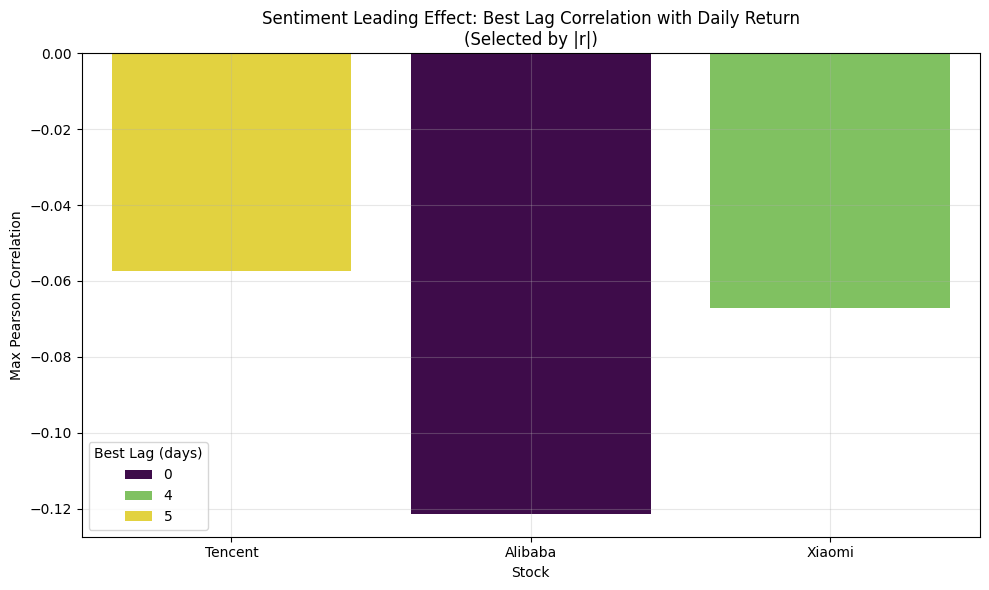


滞后相关性总结表（绝对值最强）：
     Stock  Best Lag (days)  Max Pearson
0  Tencent                5      -0.0575
1  Alibaba                0      -0.1213
2   Xiaomi                4      -0.0672


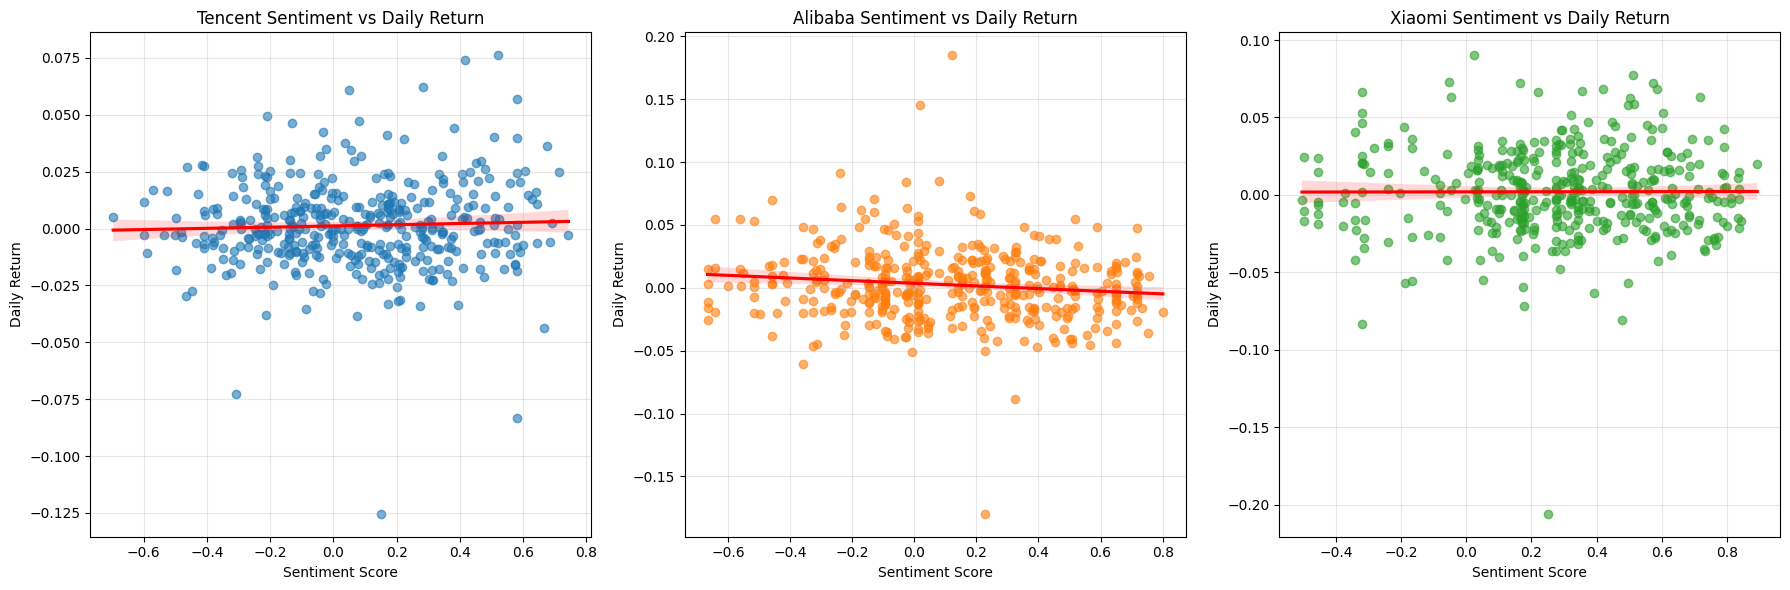

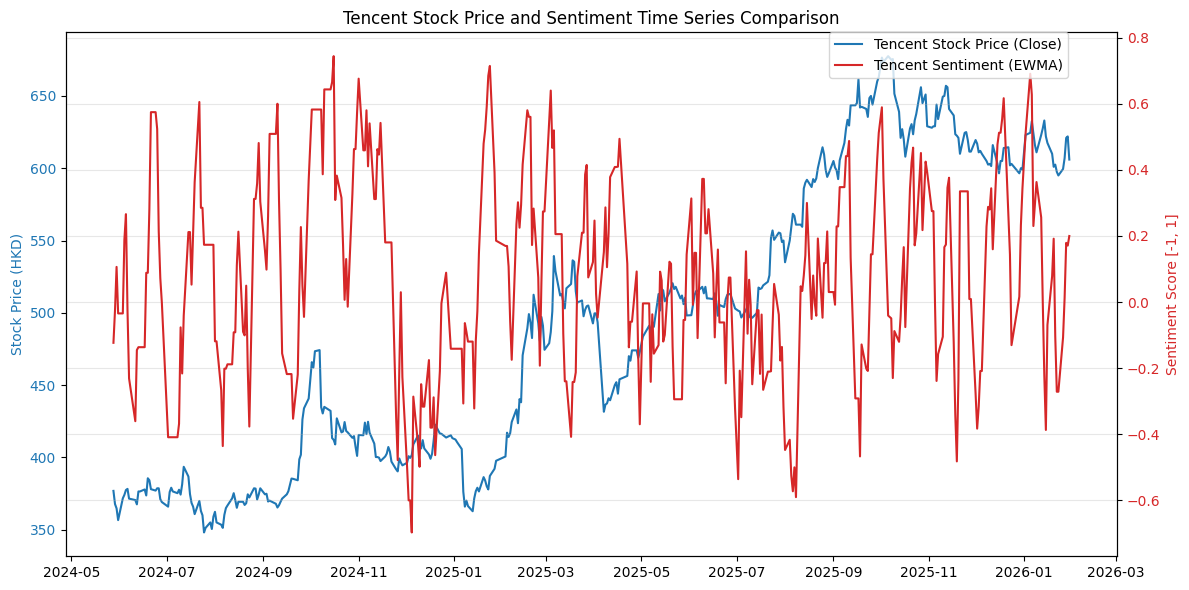

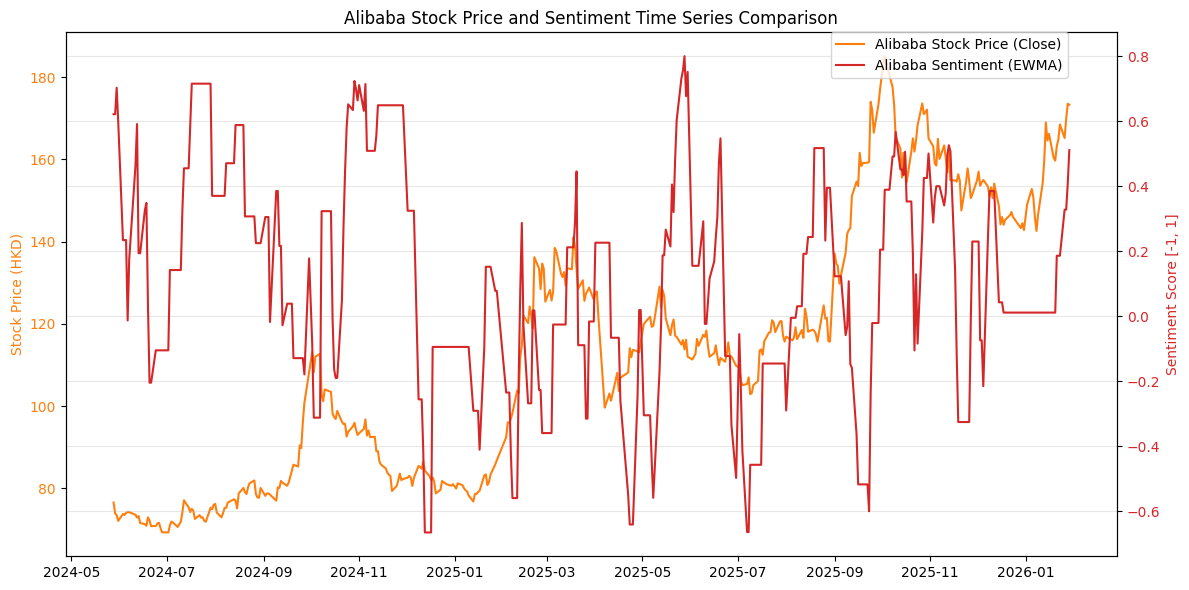

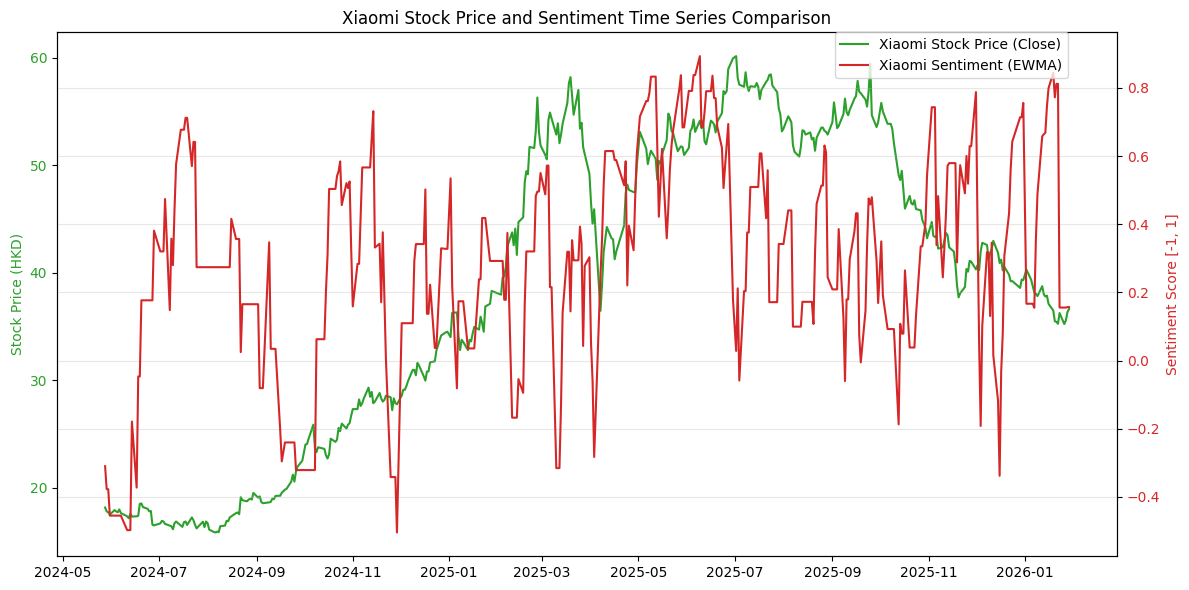

In [9]:
# ===================== 三只股票情绪-股价可视化 =====================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

print("=== 股票情绪-股价可视化 ===")

if 'results' not in globals() or len(results) == 0:
    print("请先运行前一个 cell 生成 results")
else:
    # 中文-英文映射
    stock_map = {
        '腾讯': 'Tencent',
        '阿里巴巴': 'Alibaba',
        '小米': 'Xiaomi'
    }
   
    # 1.滞后相关性对比柱状图
    lag_data = []
    for df in results:
        stock_cn = df['stock'].iloc[0]
        stock_en = stock_map.get(stock_cn, stock_cn)
        
        #绝对值最大 lag
        max_abs_r = -np.inf
        best_lag = 0
        actual_r = 0
        
        # 新增：正相关最佳 lag 和 负相关最佳 lag 
        max_pos_r = -np.inf
        best_pos_lag = 0
        max_neg_r = np.inf
        best_neg_lag = 0
        
        for lag in range(0, 6):
            temp = df.copy()
            temp['sent_lag'] = temp['sentiment'].shift(lag)
            temp = temp.dropna()
            if len(temp) > 20:
                r, _ = pearsonr(temp['sent_lag'], temp['ret'])
                
                # 绝对值最大
                if abs(r) > max_abs_r:
                    max_abs_r = abs(r)
                    actual_r = r
                    best_lag = lag
                
                # 正相关最佳
                if r > max_pos_r:
                    max_pos_r = r
                    best_pos_lag = lag
                
                # 负相关最佳
                if r < max_neg_r:
                    max_neg_r = r
                    best_neg_lag = lag
        
        # 存入柱状图数据
        lag_data.append({
            'Stock': stock_en,
            'Best Lag (days)': best_lag,
            'Max Pearson': round(actual_r, 4)
        })
        
        print(f"\n{stock_en}（{stock_cn}）")
        print(f"   正相关最佳 lag： lag {best_pos_lag} → {max_pos_r:.4f}")
        print(f"   负相关最佳 lag： lag {best_neg_lag} → {max_neg_r:.4f}")
   
    # 柱状图
    df_lag = pd.DataFrame(lag_data)
   
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_lag, x='Stock', y='Max Pearson', hue='Best Lag (days)', palette='viridis')
    plt.title('Sentiment Leading Effect: Best Lag Correlation with Daily Return\n(Selected by |r|)')
    plt.ylabel('Max Pearson Correlation')
    plt.xlabel('Stock')
    plt.legend(title='Best Lag (days)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('data/images/lag_correlation_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
   
    print("\n滞后相关性总结表（绝对值最强）：")
    print(df_lag)
    
    # 2. 三只股票散点回归图
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    colors = {'Tencent': '#1f77b4', 'Alibaba': '#ff7f0e', 'Xiaomi': '#2ca02c'}
   
    for i, df in enumerate(results):
        stock_cn = df['stock'].iloc[0]
        stock_en = stock_map.get(stock_cn, stock_cn)
        ax = axes[i]
        sns.regplot(
            data=df,
            x='sentiment',
            y='ret',
            scatter_kws={'alpha': 0.6, 'color': colors.get(stock_en, '#9467bd')},
            line_kws={'color': 'red'},
            ax=ax
        )
        ax.set_title(f'{stock_en} Sentiment vs Daily Return')
        ax.set_xlabel('Sentiment Score')
        ax.set_ylabel('Daily Return')
        ax.grid(True, alpha=0.3)
   
    plt.tight_layout()
    plt.savefig('data/images/sentiment_vs_return_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. 双轴时序对比图
    for df in results:
        stock_cn = df['stock'].iloc[0]
        stock_en = stock_map.get(stock_cn, stock_cn)
       
        ticker_map = {'Tencent': '00700', 'Alibaba': '09988', 'Xiaomi': '01810'}
        ticker = ticker_map[stock_en]
        df_price_temp = pd.read_csv("data/hk_stocks.csv", parse_dates=['date'], date_format='%Y/%m/%d')
        df_price_temp['Ticker'] = df_price_temp['Ticker'].astype(str).str.zfill(5)
        df_p = df_price_temp[df_price_temp['Ticker'] == ticker].set_index('date')
       
        df_plot = df_p[['close']].join(df[['sentiment']], how='inner')
       
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax1.plot(df_plot.index, df_plot['close'], color=colors.get(stock_en, '#1f77b4'),
                 label=f'{stock_en} Stock Price (Close)')
        ax1.set_ylabel('Stock Price (HKD)', color=colors.get(stock_en, '#1f77b4'))
        ax1.tick_params(axis='y', labelcolor=colors.get(stock_en, '#1f77b4'))
       
        ax2 = ax1.twinx()
        ax2.plot(df_plot.index, df_plot['sentiment'], color='#d62728',
                 label=f'{stock_en} Sentiment (EWMA)')
        ax2.set_ylabel('Sentiment Score [-1, 1]', color='#d62728')
        ax2.tick_params(axis='y', labelcolor='#d62728')
       
        plt.title(f'{stock_en} Stock Price and Sentiment Time Series Comparison')
        fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95))
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
# ===================== 诊断：为什么阿里相关性为负 =====================
import pandas as pd
import numpy as np

# 加载阿里数据（用前面生成的 results）
ali_df = [df for df in results if df['stock'].iloc[0] == '阿里巴巴'][0].copy()

# 高/低情绪分组（中位数以上为高）
median_sent = ali_df['sentiment'].median()
high_sent = ali_df[ali_df['sentiment'] > median_sent]
low_sent  = ali_df[ali_df['sentiment'] <= median_sent]

print("=== 阿里巴巴情绪 vs 回报诊断 ===")
print(f"高情绪日（>中位数）平均回报: {high_sent['ret'].mean():.4f}")
print(f"低情绪日（<=中位数）平均回报: {low_sent['ret'].mean():.4f}")
print(f"高情绪日回报是否更低？ → {'是（负相关）' if high_sent['ret'].mean() < low_sent['ret'].mean() else '否'}")

# 看极端日（Top 10 正面情绪日）
top10 = ali_df.nlargest(10, 'sentiment')
print("\nTop 10 高情绪日回报：")
print(top10[['sentiment', 'ret']].round(4))